In [1]:
import pandas as pd

In [3]:
from google.colab import files
uploaded = files.upload()

Saving ab_data.csv to ab_data.csv


In [4]:
df = pd.read_csv("ab_data.csv")

In [5]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [8]:
df["group"].value_counts()

,count
group,
treatment,147276
control,147202


In [9]:
df["landing_page"].value_counts()

,count
landing_page,
old_page,147239
new_page,147239


In [10]:
df["converted"].value_counts()

,count
converted,
0,259241
1,35237


In [11]:
df["converted"].mean()

np.float64(0.11965919355605512)

In [13]:
df.groupby("group")["converted"].mean()

,converted
group,
control,0.120399
treatment,0.118920


# Business Problem

A company has introduced a new landing page and wants to determine whether it improves user conversion rates compared with the existing landing page.

In [14]:
import pandas as pd

table = pd.crosstab(
    df["group"],
    df["converted"]
)

table

converted,0,1
group,,
control,129479,17723
treatment,129762,17514


# Hypothesis Testing

H0: The conversion rate of the control and treatment groups is the same.

H1: The conversion rates are different.

In [15]:
from scipy.stats import chi2_contingency

chi2,p,dof,expected = chi2_contingency(table)

print("p-value:", p)

p-value: 0.2182316121631168


# Statistical Conclusion

(To be completed after observing the p-value.)

# Statistical Conclusion

The chi-square test produced a p-value of 0.2182.

Since the p-value is greater than the significance level of 0.05, the null hypothesis cannot be rejected.

There is insufficient statistical evidence to conclude that the new landing page performs differently from the existing landing page.

# Business Recommendation

Although the treatment group showed a slightly lower conversion rate than the control group, the difference was not statistically significant.

Based on the available data, there is insufficient evidence to justify replacing the existing landing page with the new version.

Additional experimentation or redesign may be required before deployment.

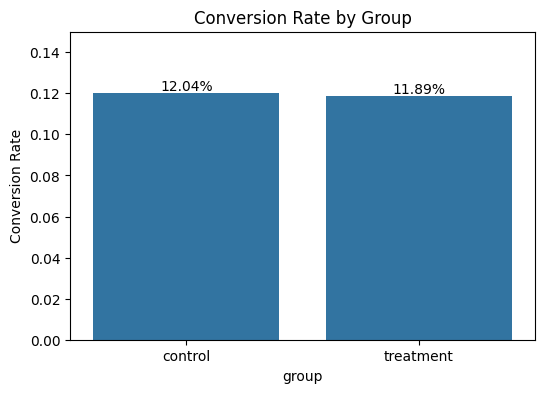

In [18]:
conversion_rates = (
    df.groupby("group")["converted"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=conversion_rates,
    x="group",
    y="converted"
)

for i,row in conversion_rates.iterrows():
    ax.text(
        i,
        row["converted"] + 0.001,
        f"{row['converted']:.2%}",
        ha="center"
    )

plt.ylim(0,0.15)

plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")

plt.show()

In [19]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [21]:
df["date"] = df["timestamp"].dt.date

In [22]:
daily_conversion = (
    df.groupby("date")["converted"]
    .mean()
    .reset_index()
)

daily_conversion.head()

,date,converted
0,2017-01-02,0.122774
1,2017-01-03,0.113633
2,2017-01-04,0.119166
3,2017-01-05,0.118790
4,2017-01-06,0.120195


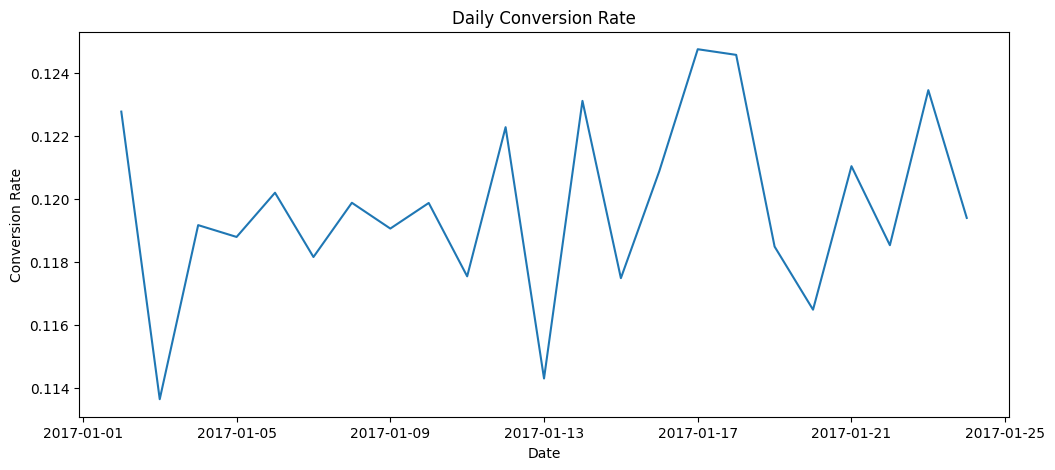

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_conversion["date"],
    daily_conversion["converted"]
)

plt.title("Daily Conversion Rate")
plt.xlabel("Date")
plt.ylabel("Conversion Rate")

plt.show()

In [24]:
daily_group = (
    df.groupby(
        ["date","group"]
    )["converted"]
    .mean()
    .reset_index()
)

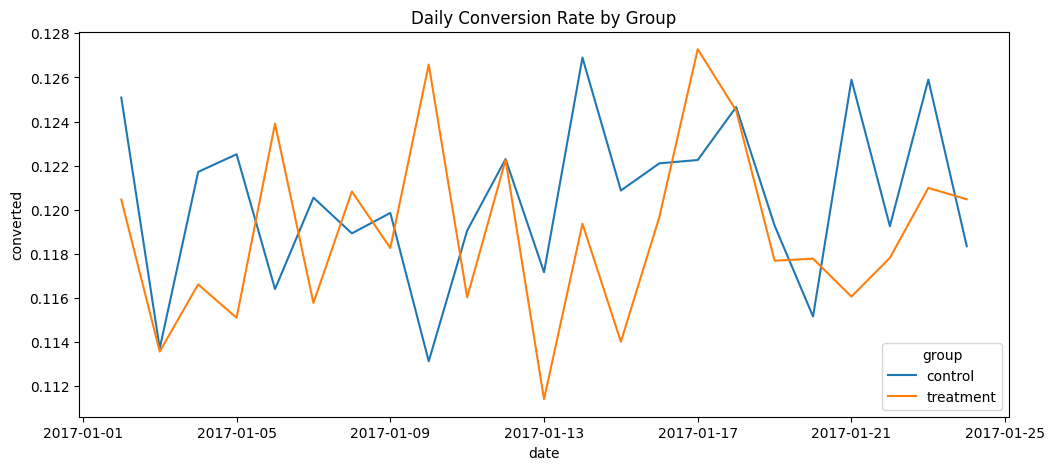

In [25]:
import seaborn as sns

plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_group,
    x="date",
    y="converted",
    hue="group"
)

plt.title(
    "Daily Conversion Rate by Group"
)

plt.show()

In [26]:
from google.colab import files

uploaded = files.upload()

Saving countries.csv to countries.csv


In [27]:
countries = pd.read_csv(
    "countries.csv"
)

countries.head()

,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [28]:
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user_id  290584 non-null  int64 
 1   country  290584 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


In [29]:
df2 = df.merge(
    countries,
    on="user_id"
)

df2.head()

,user_id,timestamp,group,landing_page,converted,date,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,2017-01-21,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,2017-01-12,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,2017-01-11,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,2017-01-08,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,2017-01-21,US


In [30]:
df2["country"].value_counts()

,count
country,
US,206364
UK,73419
CA,14695


In [31]:
df2.groupby(
    "country"
)["converted"].mean()

,converted
country,
CA,0.115890
UK,0.120582
US,0.119599


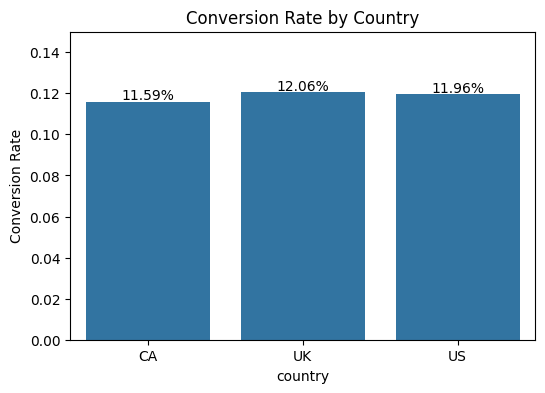

In [33]:
country_conv = (
    df2.groupby("country")["converted"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=country_conv,
    x="country",
    y="converted"
)

for i,row in country_conv.iterrows():
    ax.text(
        i,
        row["converted"] + 0.001,
        f"{row['converted']:.2%}",
        ha="center"
    )

plt.ylim(0,0.15)

plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate")

plt.show()

In [34]:
countries = pd.read_csv("countries.csv")

df2 = df.merge(
    countries,
    on="user_id"
)

In [35]:
df2["country"].value_counts()

,count
country,
US,206364
UK,73419
CA,14695


In [36]:
df2.groupby("country")["converted"].mean()

,converted
country,
CA,0.115890
UK,0.120582
US,0.119599


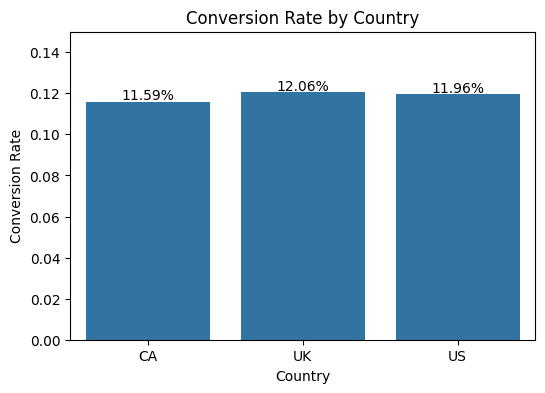

In [38]:
country_conv = (
    df2.groupby("country")["converted"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=country_conv,
    x="country",
    y="converted"
)

for i,row in country_conv.iterrows():
    ax.text(
        i,
        row["converted"] + 0.001,
        f"{row['converted']:.2%}",
        ha="center"
    )

plt.ylim(0,0.15)

plt.title("Conversion Rate by Country")
plt.ylabel("Conversion Rate")
plt.xlabel("Country")

plt.show()

# Key Findings

- Total observations: 294,478
- Overall conversion rate: 11.97%
- Control group conversion rate: 12.04%
- Treatment group conversion rate: 11.89%
- Chi-square test p-value: 0.2182
- No statistically significant difference was detected.
- UK showed the highest conversion rate among the countries analysed.

# Business Recommendation

The new landing page did not demonstrate a statistically significant improvement in conversion rates.

Based on the available evidence, deployment of the treatment page is not recommended.

Future experiments may focus on alternative page designs and further user segmentation.